In [1]:
import pandas as pd
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import EarlyStoppingCallback
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

C:\Users\redwh\anaconda3\envs\ml-dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
df = pd.read_csv("data/agnews_clean.csv")
print(df.head())
print(df.columns)

                                                text     label
0  Wall St. Bears Claw Back Into the Black (Reute...  Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...  Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...  Business
3  Iraq Halts Oil Exports from Main Southern Pipe...  Business
4  Oil prices soar to all-time record, posing new...  Business
Index(['text', 'label'], dtype='object')


In [3]:
label_map = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Sci/Tech": 3
}

df['label'] = df['label'].map(label_map).astype(int)

In [4]:
print(df['label'].unique())
print(df['label'].dtype)

[2 3 1 0]
int64


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

In [6]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds   = Dataset.from_pandas(val_df, preserve_index=False)

dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
})


In [7]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [8]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [9]:
from transformers import AutoConfig

# 1. Cấu hình thêm Dropout (Tăng độ khó cho model)
config = AutoConfig.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4,
    dropout=0.3,            # Tăng dropout của lớp ẩn lên 30%
    attention_probs_dropout_prob=0.3 # Tăng dropout của attention lên 30%
)

# 2. Khởi tạo model với cấu hình mới
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    config=config
)

print("Đã khởi tạo model với Dropout cao (0.3) để giảm Overfitting!")
print(model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Đã khởi tạo model với Dropout cao (0.3) để giảm Overfitting!
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn

In [10]:
# # Option 1: Head-only (freeze hết encoder)
# for name, param in model.named_parameters():
#     if "distilbert" in name:
#         param.requires_grad = False

# # Option 2: Unfreeze 2 layer cuối
#for name, param in model.named_parameters():
#    if "distilbert" in name:
#       param.requires_grad = False
#   if "distilbert.transformer.layer.4" in name or "distilbert.transformer.layer.5" in name:
#       param.requires_grad = True

# Option 3: Full fine-tuning
for param in model.parameters():
    param.requires_grad = True


In [11]:
for name, param in model.named_parameters():
    print(f"{name}, {param.requires_grad}")


distilbert.embeddings.word_embeddings.weight, True
distilbert.embeddings.position_embeddings.weight, True
distilbert.embeddings.LayerNorm.weight, True
distilbert.embeddings.LayerNorm.bias, True
distilbert.transformer.layer.0.attention.q_lin.weight, True
distilbert.transformer.layer.0.attention.q_lin.bias, True
distilbert.transformer.layer.0.attention.k_lin.weight, True
distilbert.transformer.layer.0.attention.k_lin.bias, True
distilbert.transformer.layer.0.attention.v_lin.weight, True
distilbert.transformer.layer.0.attention.v_lin.bias, True
distilbert.transformer.layer.0.attention.out_lin.weight, True
distilbert.transformer.layer.0.attention.out_lin.bias, True
distilbert.transformer.layer.0.sa_layer_norm.weight, True
distilbert.transformer.layer.0.sa_layer_norm.bias, True
distilbert.transformer.layer.0.ffn.lin1.weight, True
distilbert.transformer.layer.0.ffn.lin1.bias, True
distilbert.transformer.layer.0.ffn.lin2.weight, True
distilbert.transformer.layer.0.ffn.lin2.bias, True
distilbe

In [12]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")


Total params: 66,956,548
Trainable params: 66,956,548


In [13]:
tokenized_dataset = dataset.map(
    tokenize,
    batched=True
)

print(tokenized_dataset["train"][0])

Map: 100%|██████████| 12000/12000 [00:00<00:00, 22804.94 examples/s]

{'text': '10 seconds that change everything ATHENS - Ten seconds. Barely time enough to tie a shoe, wash a glass, get the paper off the porch. But when the moment comes, and eight men kneel at their blocks and peer down the empty, waiting track, it is as if the entire Olympics stop to watch.', 'label': 1, 'input_ids': [101, 2184, 3823, 2008, 2689, 2673, 7571, 1011, 2702, 3823, 1012, 4510, 2051, 2438, 2000, 5495, 1037, 10818, 1010, 9378, 1037, 3221, 1010, 2131, 1996, 3259, 2125, 1996, 7424, 1012, 2021, 2043, 1996, 2617, 3310, 1010, 1998, 2809, 2273, 6181, 2140, 2012, 2037, 5991, 1998, 8152, 2091, 1996, 4064, 1010, 3403, 2650, 1010, 2009, 2003, 2004, 2065, 1996, 2972, 3783, 2644, 2000, 3422, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [15]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=15,
    warmup_ratio=0.1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    report_to="none"
)

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.237100,0.204485,0.930667,0.930621
2,0.191200,0.177208,0.939417,0.939260
3,0.154400,0.178476,0.943667,0.943476
4,0.127100,0.181831,0.941917,0.941811
5,0.098300,0.193045,0.946167,0.946174
6,0.078300,0.216103,0.943583,0.943500
7,0.070400,0.240266,0.944750,0.944708
8,0.057300,0.278911,0.939667,0.939600
9,0.048200,0.293075,0.942083,0.942167
10,0.038000,0.337845,0.943167,0.943085


TrainOutput(global_step=50625, training_loss=0.09442006092542483, metrics={'train_runtime': 9267.4482, 'train_samples_per_second': 174.805, 'train_steps_per_second': 5.463, 'total_flos': 5.365120997376e+16, 'train_loss': 0.09442006092542483, 'epoch': 15.0})

In [18]:
# Đánh giá trên tập validation (tập bạn đã chia 12k mẫu)
eval_results = trainer.evaluate()

print("Kết quả đánh giá trên validation set:")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

Kết quả đánh giá trên validation set:
eval_loss: 0.1772
eval_accuracy: 0.9394
eval_f1_macro: 0.9393
eval_runtime: 16.0881
eval_samples_per_second: 745.8930
eval_steps_per_second: 23.3090
epoch: 15.0000


In [19]:
# Dự đoán trên toàn bộ validation set
predictions = trainer.predict(tokenized_dataset["validation"])

# predictions là một NamedTuple chứa:
# - predictions.predictions: logits (shape: [12000, 4])
# - predictions.label_ids: nhãn thật (shape: [12000])
# - predictions.metrics: các metric đã tính

print("Metrics từ predict:")
print(predictions.metrics)

# Chuyển logits thành nhãn dự đoán
import numpy as np
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# In ví dụ 10 mẫu đầu
print("\nVí dụ 10 mẫu đầu (true label vs predicted):")
for i in range(10):
    true_text = tokenized_dataset["validation"][i]["text"][:100] + "..."  # cắt ngắn để dễ xem
    print(f"Text: {true_text}")
    print(f"True: {labels[i]} | Pred: {preds[i]}")
    print("-" * 80)

Metrics từ predict:
{'test_loss': 0.17720770835876465, 'test_accuracy': 0.9394166666666667, 'test_f1_macro': 0.939260164718052, 'test_runtime': 16.3775, 'test_samples_per_second': 732.714, 'test_steps_per_second': 22.897}

Ví dụ 10 mẫu đầu (true label vs predicted):
Text: Orange Unveils 3G Phones in Long-Delayed Launch  LONDON/PARIS (Reuters) - Orange unveiled its  third...
True: 3 | Pred: 3
--------------------------------------------------------------------------------
Text: Rival Technologies Vie for 'Green' Car of Tomorrow  PARIS (Reuters) - Carmakers presented new-age au...
True: 3 | Pred: 3
--------------------------------------------------------------------------------
Text: Charity director kidnapped in Iraq Insurgents abducted the local director of CARE International from...
True: 0 | Pred: 0
--------------------------------------------------------------------------------
Text: Canadian Bonds Gain; Rising Oil Prices May Curb Economic Growth Canadian bonds gained on concern tha

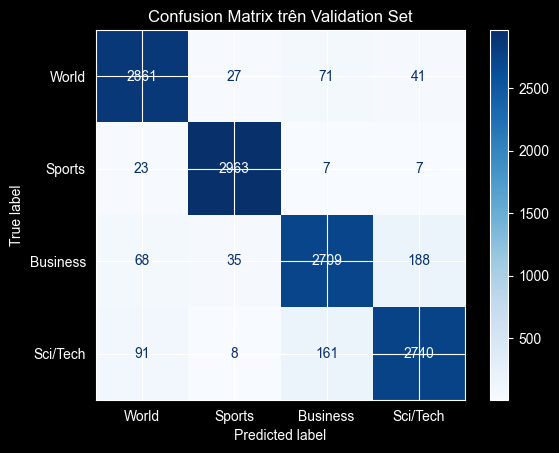

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tính confusion matrix
cm = confusion_matrix(labels, preds)

# Vẽ
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["World", "Sports", "Business", "Sci/Tech"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix trên Validation Set")
plt.show()

In [21]:
train_loss = []
eval_loss = []
epochs = []

last_train_loss = None

for log in trainer.state.log_history:
    # lưu training loss gần nhất
    if "loss" in log:
        last_train_loss = log["loss"]

    # khi tới eval (cuối epoch)
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        train_loss.append(last_train_loss)  # loss gần nhất
        epochs.append(int(log["epoch"]))

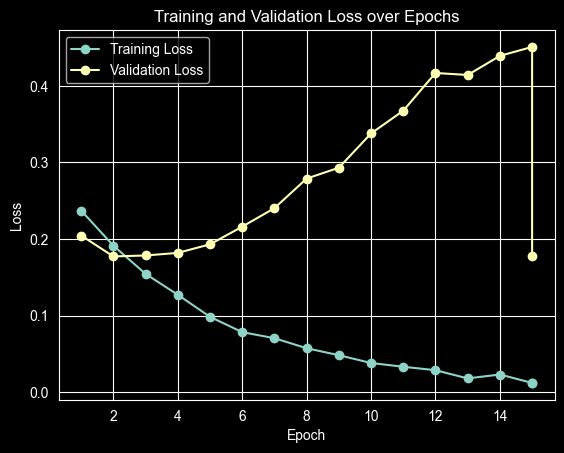

In [22]:
plt.figure()
plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, eval_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.show()


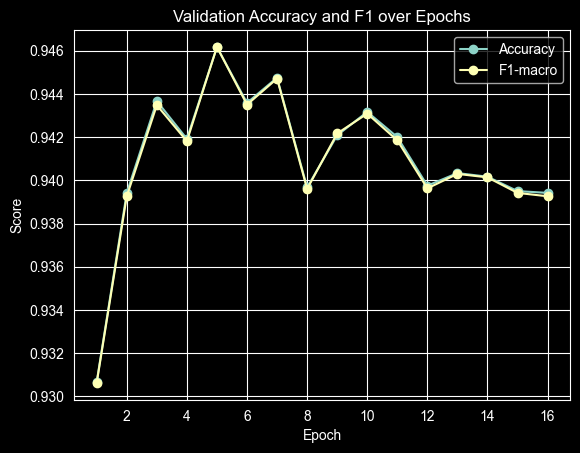

In [23]:
accuracy = []
f1 = []

for log in trainer.state.log_history:
    if "eval_accuracy" in log:
        accuracy.append(log["eval_accuracy"])
        f1.append(log["eval_f1_macro"])

epochs = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, marker='o', label="Accuracy")
plt.plot(epochs, f1, marker='o', label="F1-macro")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy and F1 over Epochs")
plt.legend()
plt.show()
